In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras.datasets import mnist

C:\Users\JimmyWu\.conda\envs\fds_cw3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


##  TensorFlow augmentation 7 methods

In [2]:
# ============================================================
# Part 2: Methods / Models / Training utils
# 第二部分：方法定义 / 模型 / 训练流程（已升级 Level 0/1/2）
# ============================================================

SEED = 42
BATCH_SIZE = 64
EPOCHS = 10

tf.random.set_seed(SEED)
np.random.seed(SEED)

# -----------------------------
# EN: A safe "no-op" layer for Method 0 (no augmentation).
# CN: 用于 Method 0 的“空增强层”，避免 Sequential 没有 layer 报错
# -----------------------------
class IdentityLayer(tf.keras.layers.Layer):
    def call(self, x, training=None):
        return x

# -----------------------------
# Level 2 (Learning/Semantic): MixUp helper
# EN: MixUp for batch (x, y). y will be one-hot.
# CN: MixUp 是“学习/语义增强”的代表：按 batch 混合两张图与标签（需要 one-hot 标签）
# -----------------------------
def mixup_batch(x, y_onehot, alpha=0.2):
    """
    EN: Apply MixUp on a batch.
    CN: 对一个 batch 做 MixUp（x与x'线性混合，y也线性混合）
    """
    batch_size = tf.shape(x)[0]
    # EN: Sample lambda from Beta(alpha, alpha).
    # CN: 从 Beta 分布采样混合系数 lambda
    lam = tf.random.gamma(shape=[batch_size], alpha=alpha)
    lam2 = tf.random.gamma(shape=[batch_size], alpha=alpha)
    lam = lam / (lam + lam2 + 1e-8)  # (batch,)

    lam_x = tf.reshape(lam, [batch_size, 1, 1, 1])
    lam_y = tf.reshape(lam, [batch_size, 1])

    # EN: Shuffle within batch.
    # CN: batch 内打乱以配对另一张图
    idx = tf.random.shuffle(tf.range(batch_size))
    x2 = tf.gather(x, idx)
    y2 = tf.gather(y_onehot, idx)

    x_mix = x * lam_x + x2 * (1.0 - lam_x)
    y_mix = y_onehot * lam_y + y2 * (1.0 - lam_y)
    return x_mix, y_mix

# -----------------------------
# Level 2 (Learning/Semantic): RandAugment-lite (SAFE)
# EN: Define layers ONCE outside tf.data map to avoid build/tracing errors.
# CN: 关键修复点：不要在 tf.data.map() 里创建 Keras layer，否则会报错/疯狂 retracing
# -----------------------------
RA_ROT = tf.keras.layers.RandomRotation(0.08)  # create once

def randaugment_lite(img, is_rgb: bool, strength=0.2):
    """
    EN: A light RandAugment-style function using safe TF ops.
    CN: 轻量 RandAugment（学习/语义增强方向的一种“更强策略”示例）
        注意：这里只用 TF 原生算子 + 预创建的旋转层，保证 tf.data.map 可运行。
    """
    x = tf.cast(img, tf.float32)

    # EN: Save original size for crop-back.
    # CN: 保存原尺寸，pad 后再随机裁回原尺寸，避免 shape 推断问题
    orig_h = tf.shape(x)[0]
    orig_w = tf.shape(x)[1]
    c = tf.shape(x)[-1]

    # ---- Flip (RGB only) ----
    # EN: Flip is meaningful for many RGB datasets.
    # CN: 翻转对多数 RGB 数据集合理；MNIST/Fashion 一般不建议（数字/衣物方向敏感）
    if is_rgb:
        x = tf.cond(tf.random.uniform([]) < 0.5,
                    lambda: tf.image.flip_left_right(x),
                    lambda: x)

    # ---- Color jitter (RGB only) ----
    # EN: Brightness/contrast jitter for RGB.
    # CN: 亮度/对比度扰动仅对 RGB 有意义，灰度可能破坏结构信息
    if is_rgb:
        def color_jitter():
            y = tf.image.random_brightness(x, max_delta=strength)
            y = tf.image.random_contrast(y, lower=1.0-strength, upper=1.0+strength)
            return y
        x = tf.cond(tf.random.uniform([]) < 0.7, color_jitter, lambda: x)

    # ---- Translation via pad + random crop ----
    # EN: Pad then crop back to original size.
    # CN: 平移用 pad+crop 实现（稳、可控），crop 的 size 必须回到原尺寸
    def translate():
        pad = 4
        y = tf.image.resize_with_crop_or_pad(x, orig_h + pad, orig_w + pad)
        y = tf.image.random_crop(y, size=[orig_h, orig_w, c])
        return y
    x = tf.cond(tf.random.uniform([]) < 0.7, translate, lambda: x)

    # ---- Small rotation (use global layer) ----
    # EN: Use pre-created RandomRotation layer.
    # CN: 使用外部预创建层，避免 tf.data 内创建对象导致报错
    def rotate():
        y = RA_ROT(tf.expand_dims(x, 0), training=True)[0]
        return y
    x = tf.cond(tf.random.uniform([]) < 0.7, rotate, lambda: x)

    return x


# -----------------------------
# EN: Choose TensorFlow augmentation by method_id.
# CN: 按 method_id 选择增强策略（升级版：Level 0/1/2）
#
# Method mapping (建议你在报告里写清楚):
# - Method 0: Level 0  No augmentation
# - Method 1: Level 1  Rotation
# - Method 2: Level 1  Translation
# - Method 3: Level 1  Zoom
# - Method 4: Level 1  Rotation + Translation + Zoom (+ Contrast for RGB)
# - Method 5: Level 2  MixUp (semantic/learning augmentation)
# - Method 6: Level 2  RandAugment-lite (stronger learned-style policy)
# -----------------------------
def get_augmentation(method_id: int, is_rgb: bool) -> tf.keras.Model:
    """
    EN: Return a Keras Sequential augmentation model for Level 0/1.
    CN: Level 0/1 用 Keras layer 实现；Level 2 的 MixUp/RandAugment 在 tf.data.map 中单独处理。
    """
    if method_id == 0:
        return tf.keras.Sequential([IdentityLayer()], name="aug_none")

    layers = []
    if method_id == 1:
        layers.append(tf.keras.layers.RandomRotation(0.08))
    elif method_id == 2:
        layers.append(tf.keras.layers.RandomTranslation(0.08, 0.08))
    elif method_id == 3:
        layers.append(tf.keras.layers.RandomZoom(0.10))
    elif method_id == 4:
        layers.append(tf.keras.layers.RandomRotation(0.08))
        layers.append(tf.keras.layers.RandomTranslation(0.08, 0.08))
        layers.append(tf.keras.layers.RandomZoom(0.10))
        if is_rgb:
            layers.append(tf.keras.layers.RandomContrast(0.10))
    else:
        # EN: For Level 2 methods, return Identity here (handled in run_one_method).
        # CN: Level 2（MixUp/RandAugment）不在这里做，run_one_method 里处理
        layers.append(IdentityLayer())

    return tf.keras.Sequential(layers, name=f"aug_{method_id}")


# -----------------------------
# EN: Simple CNN baseline (same architecture across methods).
# CN: 统一 CNN 模型结构（保证对比公平）
#     注意：如果你要做“严格的增强效果对比”，模型结构尽量保持一致。
# -----------------------------
def build_cnn(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),

        tf.keras.layers.Conv2D(32, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(64, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


# -----------------------------
# EN: Train one method and return history + final train/val accuracy.
# CN: 训练单个增强方案，返回 history + 最终训练/验证准确率（用于判断过拟合）
#
# IMPORTANT:
# - Level 0/1: standard sparse labels
# - Level 2 MixUp: needs one-hot labels + categorical crossentropy
# -----------------------------
def run_one_method(X_train, y_train, X_val, y_val, input_shape, num_classes, method_id, is_rgb):
    aug = get_augmentation(method_id, is_rgb)

    # EN: Build base datasets.
    # CN: 构建基础 tf.data
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)) \
        .shuffle(min(len(X_train), 20000), seed=SEED) \
        .batch(BATCH_SIZE)

    val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE)

    # -------------------------
    # EN: For MixUp (Method 5), switch to one-hot labels and different loss.
    # CN: MixUp 需要 one-hot 标签，且用 categorical crossentropy 更合理
    # -------------------------
    use_mixup = (method_id == 5)
    use_randaug = (method_id == 6)

    if use_mixup:
        # EN: rebuild model with categorical crossentropy
        # CN: MixUp 的标签是 soft label（概率分布），所以用 categorical_crossentropy
        model = tf.keras.Sequential([
            tf.keras.layers.Input(shape=input_shape),

            tf.keras.layers.Conv2D(32, 3, activation="relu"),
            tf.keras.layers.MaxPooling2D(),

            tf.keras.layers.Conv2D(64, 3, activation="relu"),
            tf.keras.layers.MaxPooling2D(),

            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(128, activation="relu"),
            tf.keras.layers.Dense(num_classes, activation="softmax"),
        ])
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
            loss="categorical_crossentropy",
            metrics=["accuracy"]
        )

        def train_map(x, y):
            # EN: Apply base augmentation (Level 0/1) first (usually Identity for Method 5).
            # CN: 先做基础增强（对 Method 5 通常是 Identity，但保留接口一致性）
            x = aug(x, training=True)

            # EN: Convert labels to one-hot then MixUp.
            # CN: 转 one-hot + MixUp
            y_oh = tf.one_hot(tf.cast(y, tf.int32), depth=num_classes)
            x, y_oh = mixup_batch(x, y_oh, alpha=0.2)
            return x, y_oh

        def val_map(x, y):
            # EN: Validation uses clean data (no augmentation).
            # CN: 验证集不做增强，并把标签也转 one-hot 以匹配 loss
            y_oh = tf.one_hot(tf.cast(y, tf.int32), depth=num_classes)
            return x, y_oh

        train_ds2 = train_ds.map(train_map, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
        val_ds2 = val_ds.map(val_map, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

        history = model.fit(train_ds2, epochs=EPOCHS, validation_data=val_ds2, verbose=2)

    else:
        # EN: Standard training (sparse labels).
        # CN: 常规训练（sparse labels）
        model = build_cnn(input_shape, num_classes)

        def train_map(x, y):
            # EN: Level 0/1 augmentation by Keras layers.
            # CN: Level 0/1 用 Keras layer 增强
            x = aug(x, training=True)

            # EN: Level 2 RandAugment-lite (Method 6) as extra stronger policy.
            # CN: Level 2：RandAugment-lite（Method 6）在这里额外叠加
            if use_randaug:
                # EN: Apply per-image function safely via map_fn.
                # CN: 对 batch 内每张图做 randaugment_lite（安全版本）
                x = tf.map_fn(
                    lambda img: randaugment_lite(img, is_rgb=is_rgb, strength=0.2),
                    x,
                    fn_output_signature=tf.float32
                )
            return x, y

        train_ds2 = train_ds.map(train_map, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
        val_ds2 = val_ds.prefetch(tf.data.AUTOTUNE)

        history = model.fit(train_ds2, epochs=EPOCHS, validation_data=val_ds2, verbose=2)

    final_train_acc = history.history["accuracy"][-1]
    final_val_acc = history.history["val_accuracy"][-1]
    return history, final_train_acc, final_val_acc


# -----------------------------
# EN: Plot accuracy + loss curves.
# CN: 画训练/验证 accuracy 和 loss 曲线（每个 method 一张）
# -----------------------------
def plot_acc_loss(history, title_prefix=""):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label="Train Accuracy")
    plt.plot(epochs, val_acc, label="Val Accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Val Loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()


def plot_final_summary(results_dict, title="Final Train / Val Accuracy by Method"):
    """
    EN: Plot final train/val accuracy across methods as line plots.
    CN: 使用折线图展示不同方法的最终训练/验证准确率
    """
    methods = sorted(results_dict.keys())
    train_acc = [results_dict[m][0] for m in methods]
    val_acc   = [results_dict[m][1] for m in methods]

    plt.figure(figsize=(8, 5))
    plt.plot(methods, train_acc, marker="o", label="Train Accuracy")
    plt.plot(methods, val_acc, marker="s", label="Validation Accuracy")

    plt.xticks(methods)
    plt.xlabel("Method ID")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

## MNIST 


MNIST - Method 0

Epoch 1/10
875/875 - 5s - 6ms/step - accuracy: 0.9496 - loss: 0.1697 - val_accuracy: 0.9746 - val_loss: 0.0747
Epoch 2/10
875/875 - 4s - 5ms/step - accuracy: 0.9843 - loss: 0.0510 - val_accuracy: 0.9828 - val_loss: 0.0524
Epoch 3/10
875/875 - 4s - 5ms/step - accuracy: 0.9887 - loss: 0.0363 - val_accuracy: 0.9874 - val_loss: 0.0405
Epoch 4/10
875/875 - 4s - 5ms/step - accuracy: 0.9919 - loss: 0.0269 - val_accuracy: 0.9884 - val_loss: 0.0399
Epoch 5/10
875/875 - 4s - 5ms/step - accuracy: 0.9933 - loss: 0.0206 - val_accuracy: 0.9871 - val_loss: 0.0433
Epoch 6/10
875/875 - 4s - 5ms/step - accuracy: 0.9942 - loss: 0.0170 - val_accuracy: 0.9889 - val_loss: 0.0355
Epoch 7/10
875/875 - 4s - 5ms/step - accuracy: 0.9954 - loss: 0.0131 - val_accuracy: 0.9909 - val_loss: 0.0290
Epoch 8/10
875/875 - 4s - 5ms/step - accuracy: 0.9964 - loss: 0.0103 - val_accuracy: 0.9911 - val_loss: 0.0336
Epoch 9/10
875/875 - 4s - 5ms/step - accuracy: 0.9972 - loss: 0.0088 - val_accuracy: 0.9891 -

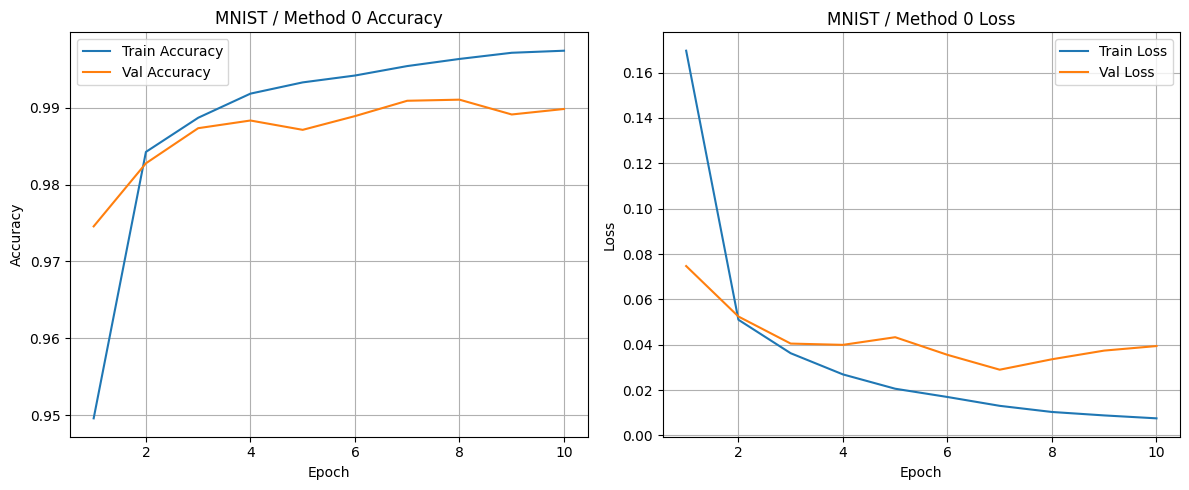


MNIST - Method 1
Epoch 1/10
875/875 - 5s - 6ms/step - accuracy: 0.9294 - loss: 0.2312 - val_accuracy: 0.9769 - val_loss: 0.0727
Epoch 2/10
875/875 - 4s - 5ms/step - accuracy: 0.9756 - loss: 0.0766 - val_accuracy: 0.9833 - val_loss: 0.0521
Epoch 3/10
875/875 - 4s - 5ms/step - accuracy: 0.9821 - loss: 0.0583 - val_accuracy: 0.9872 - val_loss: 0.0404
Epoch 4/10
875/875 - 5s - 5ms/step - accuracy: 0.9849 - loss: 0.0476 - val_accuracy: 0.9833 - val_loss: 0.0520
Epoch 5/10
875/875 - 4s - 5ms/step - accuracy: 0.9874 - loss: 0.0394 - val_accuracy: 0.9892 - val_loss: 0.0353
Epoch 6/10
875/875 - 4s - 5ms/step - accuracy: 0.9891 - loss: 0.0349 - val_accuracy: 0.9898 - val_loss: 0.0331
Epoch 7/10
875/875 - 4s - 5ms/step - accuracy: 0.9904 - loss: 0.0308 - val_accuracy: 0.9884 - val_loss: 0.0383
Epoch 8/10
875/875 - 4s - 5ms/step - accuracy: 0.9909 - loss: 0.0285 - val_accuracy: 0.9897 - val_loss: 0.0352
Epoch 9/10
875/875 - 4s - 5ms/step - accuracy: 0.9918 - loss: 0.0257 - val_accuracy: 0.9894 - 

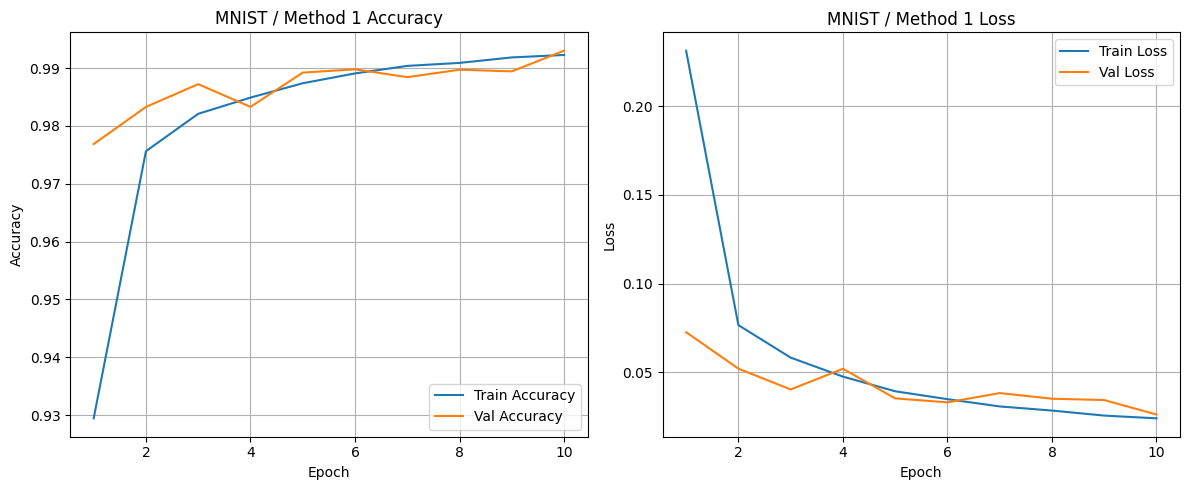


MNIST - Method 2
Epoch 1/10
875/875 - 5s - 6ms/step - accuracy: 0.9131 - loss: 0.2794 - val_accuracy: 0.9799 - val_loss: 0.0672
Epoch 2/10
875/875 - 4s - 5ms/step - accuracy: 0.9735 - loss: 0.0860 - val_accuracy: 0.9851 - val_loss: 0.0485
Epoch 3/10
875/875 - 4s - 5ms/step - accuracy: 0.9800 - loss: 0.0661 - val_accuracy: 0.9877 - val_loss: 0.0381
Epoch 4/10
875/875 - 5s - 5ms/step - accuracy: 0.9841 - loss: 0.0518 - val_accuracy: 0.9882 - val_loss: 0.0358
Epoch 5/10
875/875 - 4s - 5ms/step - accuracy: 0.9864 - loss: 0.0436 - val_accuracy: 0.9908 - val_loss: 0.0284
Epoch 6/10
875/875 - 4s - 5ms/step - accuracy: 0.9883 - loss: 0.0377 - val_accuracy: 0.9899 - val_loss: 0.0311
Epoch 7/10
875/875 - 4s - 5ms/step - accuracy: 0.9891 - loss: 0.0348 - val_accuracy: 0.9887 - val_loss: 0.0356
Epoch 8/10
875/875 - 4s - 5ms/step - accuracy: 0.9899 - loss: 0.0322 - val_accuracy: 0.9909 - val_loss: 0.0288
Epoch 9/10
875/875 - 4s - 5ms/step - accuracy: 0.9912 - loss: 0.0283 - val_accuracy: 0.9913 - 

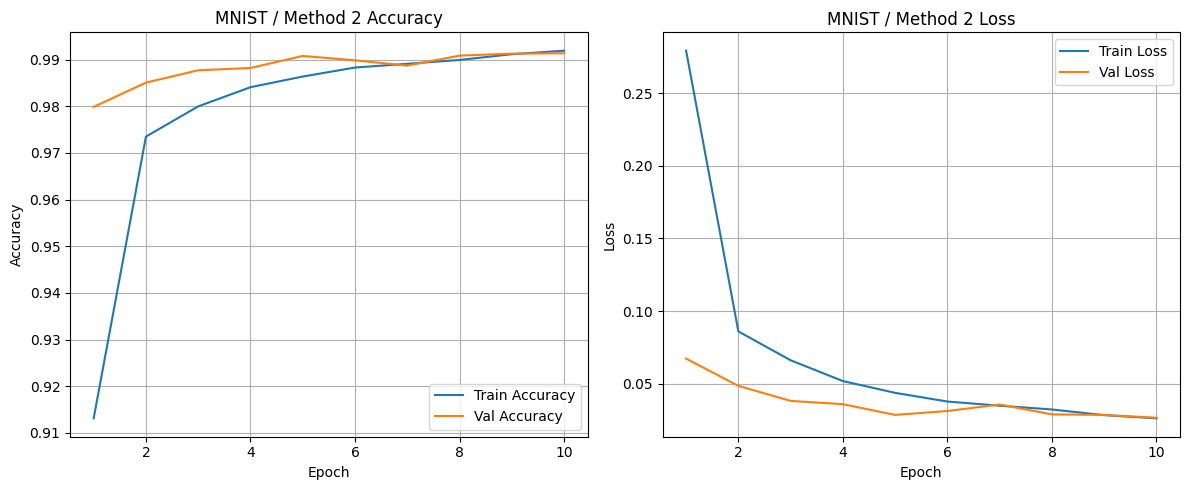


MNIST - Method 3
Epoch 1/10
875/875 - 5s - 6ms/step - accuracy: 0.9482 - loss: 0.1733 - val_accuracy: 0.9781 - val_loss: 0.0669
Epoch 2/10
875/875 - 4s - 5ms/step - accuracy: 0.9825 - loss: 0.0534 - val_accuracy: 0.9851 - val_loss: 0.0474
Epoch 3/10
875/875 - 4s - 5ms/step - accuracy: 0.9879 - loss: 0.0384 - val_accuracy: 0.9870 - val_loss: 0.0414
Epoch 4/10
875/875 - 4s - 5ms/step - accuracy: 0.9905 - loss: 0.0300 - val_accuracy: 0.9888 - val_loss: 0.0374
Epoch 5/10
875/875 - 4s - 5ms/step - accuracy: 0.9929 - loss: 0.0228 - val_accuracy: 0.9873 - val_loss: 0.0447
Epoch 6/10
875/875 - 4s - 5ms/step - accuracy: 0.9935 - loss: 0.0195 - val_accuracy: 0.9909 - val_loss: 0.0298
Epoch 7/10
875/875 - 4s - 5ms/step - accuracy: 0.9950 - loss: 0.0156 - val_accuracy: 0.9908 - val_loss: 0.0324
Epoch 8/10
875/875 - 4s - 5ms/step - accuracy: 0.9953 - loss: 0.0139 - val_accuracy: 0.9898 - val_loss: 0.0350
Epoch 9/10
875/875 - 4s - 5ms/step - accuracy: 0.9959 - loss: 0.0116 - val_accuracy: 0.9905 - 

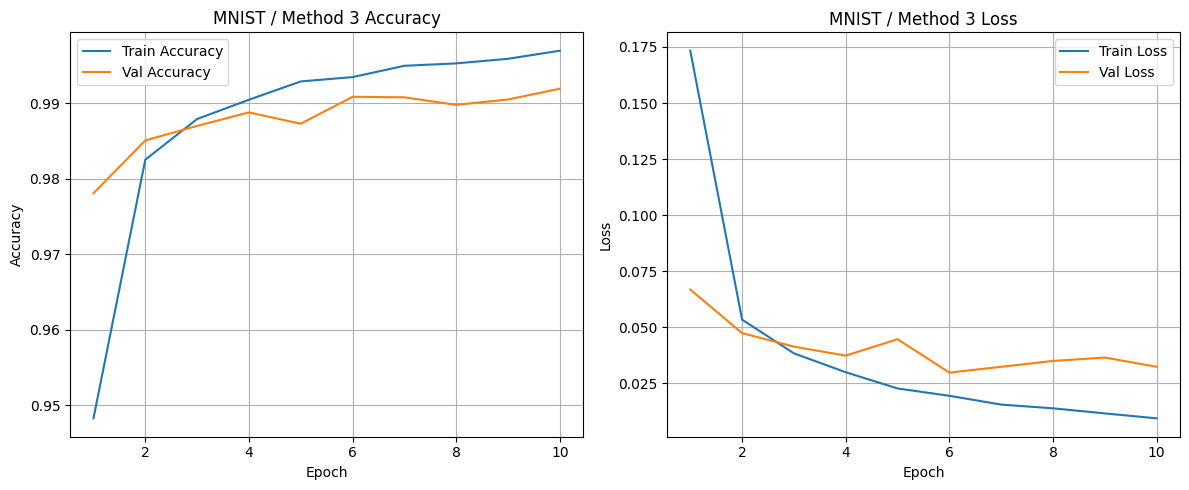


MNIST - Method 4
Epoch 1/10
875/875 - 5s - 6ms/step - accuracy: 0.8843 - loss: 0.3655 - val_accuracy: 0.9656 - val_loss: 0.1116
Epoch 2/10
875/875 - 4s - 5ms/step - accuracy: 0.9579 - loss: 0.1392 - val_accuracy: 0.9719 - val_loss: 0.0848
Epoch 3/10
875/875 - 4s - 5ms/step - accuracy: 0.9677 - loss: 0.1032 - val_accuracy: 0.9855 - val_loss: 0.0487
Epoch 4/10
875/875 - 4s - 5ms/step - accuracy: 0.9739 - loss: 0.0835 - val_accuracy: 0.9863 - val_loss: 0.0453
Epoch 5/10
875/875 - 4s - 5ms/step - accuracy: 0.9787 - loss: 0.0708 - val_accuracy: 0.9879 - val_loss: 0.0420
Epoch 6/10
875/875 - 4s - 5ms/step - accuracy: 0.9796 - loss: 0.0647 - val_accuracy: 0.9854 - val_loss: 0.0489
Epoch 7/10
875/875 - 4s - 5ms/step - accuracy: 0.9820 - loss: 0.0574 - val_accuracy: 0.9879 - val_loss: 0.0400
Epoch 8/10
875/875 - 4s - 5ms/step - accuracy: 0.9835 - loss: 0.0546 - val_accuracy: 0.9886 - val_loss: 0.0398
Epoch 9/10
875/875 - 4s - 5ms/step - accuracy: 0.9843 - loss: 0.0510 - val_accuracy: 0.9901 - 

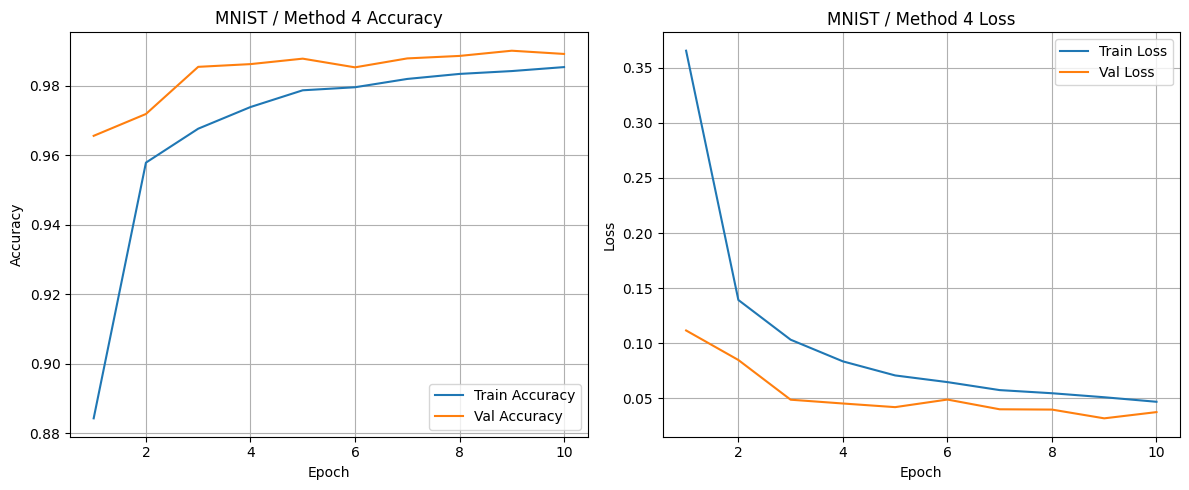


MNIST - Method 5
Epoch 1/10
875/875 - 5s - 6ms/step - accuracy: 0.9194 - loss: 0.5446 - val_accuracy: 0.9771 - val_loss: 0.0998
Epoch 2/10
875/875 - 4s - 5ms/step - accuracy: 0.9524 - loss: 0.4098 - val_accuracy: 0.9846 - val_loss: 0.0628
Epoch 3/10
875/875 - 4s - 5ms/step - accuracy: 0.9518 - loss: 0.3767 - val_accuracy: 0.9874 - val_loss: 0.0524
Epoch 4/10
875/875 - 4s - 5ms/step - accuracy: 0.9515 - loss: 0.3526 - val_accuracy: 0.9881 - val_loss: 0.0466
Epoch 5/10
875/875 - 4s - 5ms/step - accuracy: 0.9531 - loss: 0.3365 - val_accuracy: 0.9890 - val_loss: 0.0460
Epoch 6/10
875/875 - 5s - 5ms/step - accuracy: 0.9560 - loss: 0.3233 - val_accuracy: 0.9909 - val_loss: 0.0416
Epoch 7/10
875/875 - 4s - 5ms/step - accuracy: 0.9571 - loss: 0.3171 - val_accuracy: 0.9899 - val_loss: 0.0388
Epoch 8/10
875/875 - 4s - 5ms/step - accuracy: 0.9579 - loss: 0.3095 - val_accuracy: 0.9914 - val_loss: 0.0339
Epoch 9/10
875/875 - 4s - 5ms/step - accuracy: 0.9609 - loss: 0.3018 - val_accuracy: 0.9920 - 

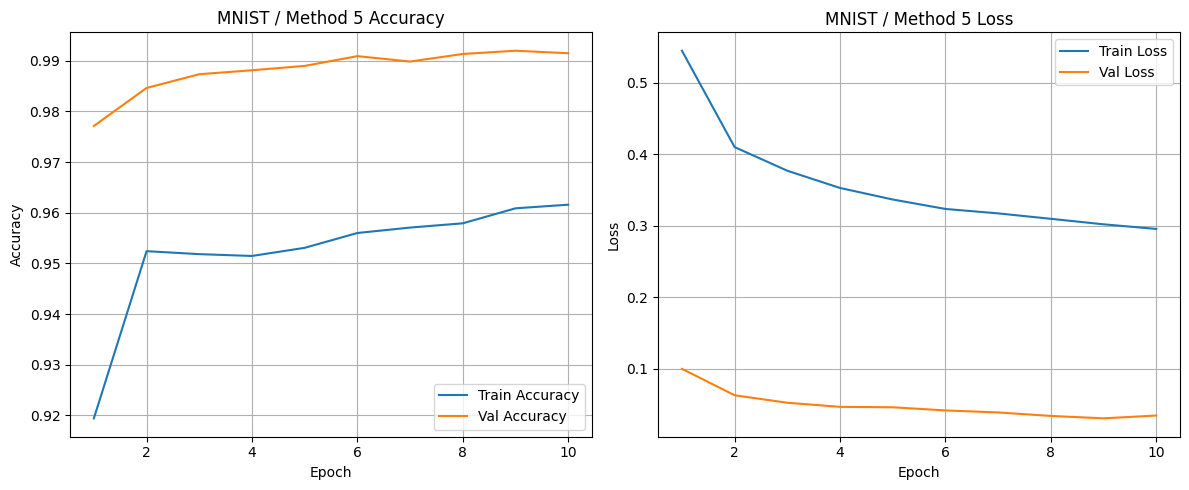


MNIST - Method 6
Epoch 1/10
875/875 - 7s - 8ms/step - accuracy: 0.8998 - loss: 0.3203 - val_accuracy: 0.9800 - val_loss: 0.0642
Epoch 2/10
875/875 - 7s - 8ms/step - accuracy: 0.9659 - loss: 0.1115 - val_accuracy: 0.9856 - val_loss: 0.0459
Epoch 3/10
875/875 - 7s - 8ms/step - accuracy: 0.9758 - loss: 0.0789 - val_accuracy: 0.9884 - val_loss: 0.0369
Epoch 4/10
875/875 - 7s - 8ms/step - accuracy: 0.9796 - loss: 0.0661 - val_accuracy: 0.9885 - val_loss: 0.0369
Epoch 5/10
875/875 - 7s - 8ms/step - accuracy: 0.9818 - loss: 0.0585 - val_accuracy: 0.9890 - val_loss: 0.0340
Epoch 6/10
875/875 - 7s - 8ms/step - accuracy: 0.9844 - loss: 0.0504 - val_accuracy: 0.9896 - val_loss: 0.0322
Epoch 7/10
875/875 - 7s - 8ms/step - accuracy: 0.9861 - loss: 0.0456 - val_accuracy: 0.9911 - val_loss: 0.0288
Epoch 8/10
875/875 - 7s - 8ms/step - accuracy: 0.9863 - loss: 0.0432 - val_accuracy: 0.9921 - val_loss: 0.0272
Epoch 9/10
875/875 - 7s - 8ms/step - accuracy: 0.9876 - loss: 0.0388 - val_accuracy: 0.9919 - 

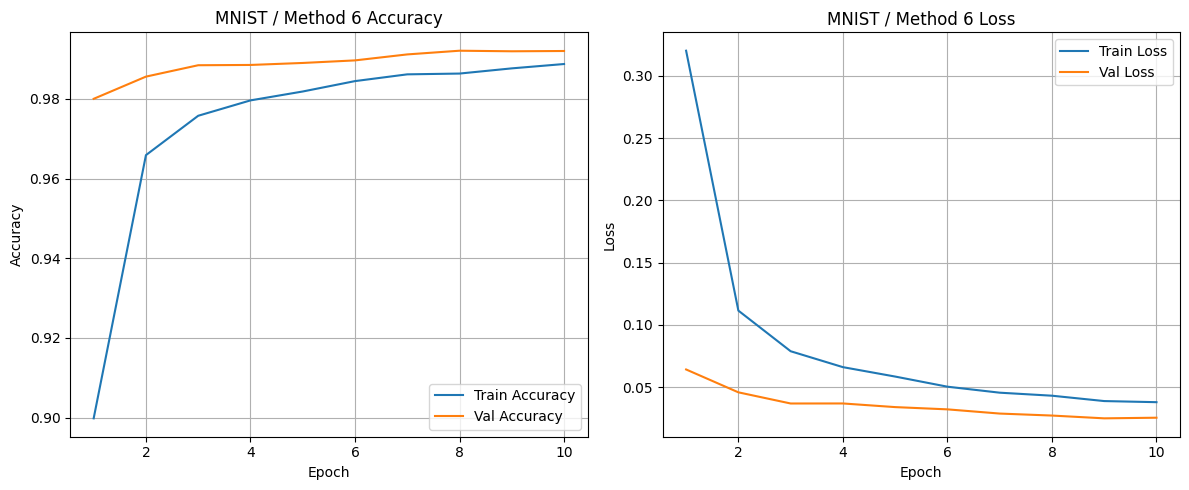


MNIST - Method 7
Epoch 1/10
875/875 - 5s - 6ms/step - accuracy: 0.9482 - loss: 0.1762 - val_accuracy: 0.9792 - val_loss: 0.0643
Epoch 2/10
875/875 - 4s - 5ms/step - accuracy: 0.9843 - loss: 0.0494 - val_accuracy: 0.9839 - val_loss: 0.0496
Epoch 3/10
875/875 - 4s - 5ms/step - accuracy: 0.9890 - loss: 0.0346 - val_accuracy: 0.9878 - val_loss: 0.0410
Epoch 4/10
875/875 - 4s - 5ms/step - accuracy: 0.9915 - loss: 0.0259 - val_accuracy: 0.9875 - val_loss: 0.0410
Epoch 5/10
875/875 - 4s - 5ms/step - accuracy: 0.9942 - loss: 0.0185 - val_accuracy: 0.9879 - val_loss: 0.0449
Epoch 6/10
875/875 - 4s - 5ms/step - accuracy: 0.9949 - loss: 0.0155 - val_accuracy: 0.9913 - val_loss: 0.0297
Epoch 7/10
875/875 - 4s - 4ms/step - accuracy: 0.9962 - loss: 0.0107 - val_accuracy: 0.9898 - val_loss: 0.0368
Epoch 8/10
875/875 - 4s - 5ms/step - accuracy: 0.9965 - loss: 0.0107 - val_accuracy: 0.9894 - val_loss: 0.0357
Epoch 9/10
875/875 - 4s - 5ms/step - accuracy: 0.9976 - loss: 0.0077 - val_accuracy: 0.9893 - 

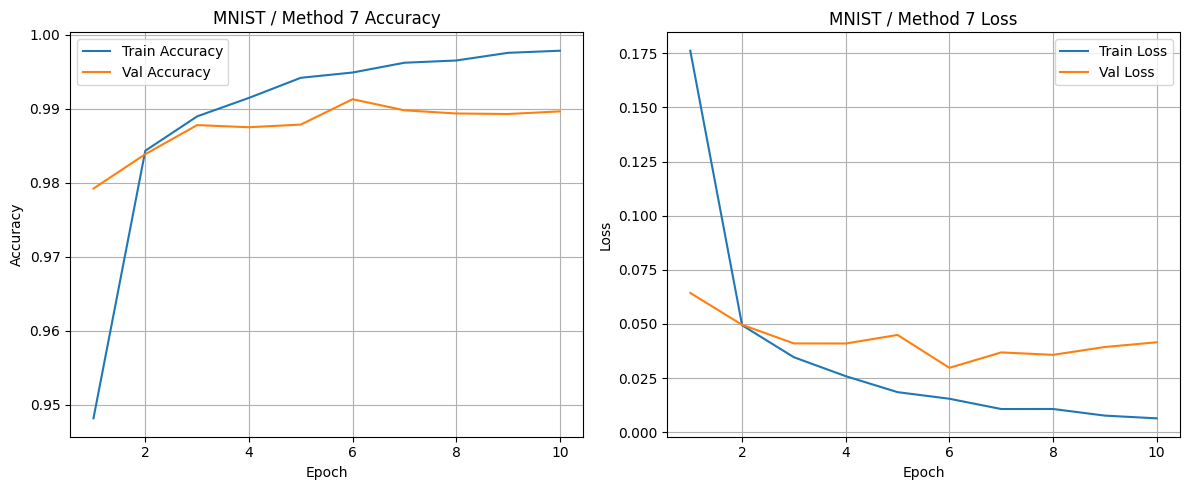


Final accuracy summary (MNIST):
Method 0: train_acc=0.9974, val_acc=0.9899
Method 1: train_acc=0.9923, val_acc=0.9930
Method 2: train_acc=0.9919, val_acc=0.9914
Method 3: train_acc=0.9970, val_acc=0.9919
Method 4: train_acc=0.9854, val_acc=0.9892
Method 5: train_acc=0.9616, val_acc=0.9915
Method 6: train_acc=0.9887, val_acc=0.9920
Method 7: train_acc=0.9978, val_acc=0.9896


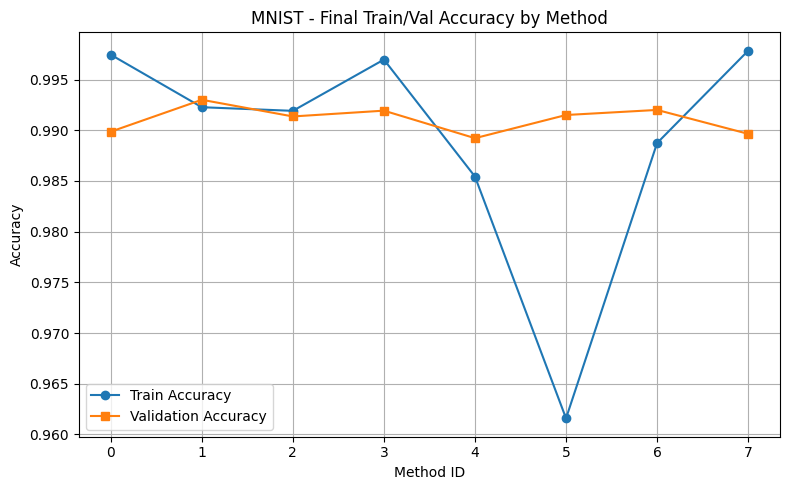

In [3]:
# =========================
# MNIST
# =========================
(X0, y0), (X1, y1) = mnist.load_data()
X = np.concatenate([X0, X1], axis=0)
y = np.concatenate([y0, y1], axis=0)

# EN: Cleaning = MinMaxScaling to [0,1] (single normalization).
# CN: 清洗=MinMaxScaling 到 [0,1]（只做一次归一化）
X = X.astype("float32")
X = (X - X.min()) / (X.max() - X.min() + 1e-8)

# EN: Add channel dim -> (N,28,28,1).
# CN: 增加通道维度以适配 CNN
X = X[..., None]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, shuffle=True
)

input_shape = (28, 28, 1)
num_classes = 10
is_rgb = False

results = {}

for method_id in range(8):
    print("\n==============================")
    print(f"MNIST - Method {method_id}")
    print("==============================")

    history, train_acc, val_acc = run_one_method(
        X_train, y_train, X_val, y_val,
        input_shape=input_shape, num_classes=num_classes,
        method_id=method_id, is_rgb=is_rgb
    )
    results[method_id] = (train_acc, val_acc)
    plot_acc_loss(history, title_prefix=f"MNIST / Method {method_id}")

print("\nFinal accuracy summary (MNIST):")
for k, (ta, va) in results.items():
    print(f"Method {k}: train_acc={ta:.4f}, val_acc={va:.4f}")

plot_final_summary(results, title="MNIST - Final Train/Val Accuracy by Method")